In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import os
import time
from tqdm.notebook import tqdm

In [51]:
DATA_DIR = '/home/inonzr/datasets/samsung/20260219_174631/'
NUM_CLASSES = 5
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3
IMAGE_SIZE = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
DATASET_MEAN = [0.5, 0.5, 0.5]
DATASET_STD = [0.5, 0.5, 0.5]


Using device: cuda


In [55]:
def calculate_dataset_stats(data_dir):
    print("Calculating mean and std for the custom Samsung dataset...")

    temp_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor()
    ])

    temp_dataset = datasets.ImageFolder(data_dir, transform=temp_transform)
    temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False, num_workers=4)

    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_images = 0

    for images, _ in tqdm(temp_loader, desc="Calculating Stats"):
        batch_size = images.size(0)
        images = images.view(batch_size, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images += batch_size

    mean /= total_images
    std /= total_images
    DATASET_MEAN = mean
    DATASET_STD = std
    print("\n" + "="*50)
    print("DATASET STATISTICS CALCULATED!")
    print(f"DATASET_MEAN = {mean.tolist()}")
    print(f"DATASET_STD  = {std.tolist()}")
    print("="*50)
    print("Please copy these values to the Hyperparameters cell at the top.\n")
    return mean, std
calculate_dataset_stats(DATA_DIR)

Calculating mean and std for the custom Samsung dataset...


Calculating Stats:   0%|          | 0/110 [00:00<?, ?it/s]


DATASET STATISTICS CALCULATED!
DATASET_MEAN = [0.5223926305770874, 0.5005241632461548, 0.49497371912002563]
DATASET_STD  = [0.14497309923171997, 0.14863280951976776, 0.14289118349552155]
Please copy these values to the Hyperparameters cell at the top.



(tensor([0.5224, 0.5005, 0.4950]), tensor([0.1450, 0.1486, 0.1429]))

In [56]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
])
print(DATASET_STD)
print(DATASET_MEAN)

[0.5, 0.5, 0.5]
[0.5, 0.5, 0.5]


In [57]:
def get_dataloaders(data_dir, batch_size):

    full_train_dataset = datasets.ImageFolder(data_dir, transform=train_transforms)
    full_val_dataset = datasets.ImageFolder(data_dir, transform=val_transforms)

    classes = full_train_dataset.classes
    dataset_size = len(full_train_dataset)

    indices = torch.randperm(dataset_size).tolist()

    split_idx = int(0.2 * dataset_size)

    val_indices = indices[:split_idx]
    train_indices = indices[split_idx:]

    train_dataset = Subset(full_train_dataset, train_indices)
    val_dataset = Subset(full_val_dataset, val_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    print(f"\nDataset loaded successfully!")
    print(f"Total images: {dataset_size}")
    print(f"Training on:  {len(train_dataset)} images (80%)")
    print(f"Validating on:{len(val_dataset)} images (20%)")
    print(f"Classes: {classes}\n")

    return train_loader, val_loader, classes

In [58]:
class SEBlock(nn.Module):

    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.GELU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.se = SEBlock(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.gelu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        out = self.gelu(out)
        return out

class SamsungDefectDetector(nn.Module):

    def __init__(self, num_classes=5):
        super(SamsungDefectDetector, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU()
        )

        self.layer1 = ResidualBlock(64, 128, stride=2)
        self.layer2 = ResidualBlock(128, 256, stride=2)
        self.layer3 = ResidualBlock(256, 512, stride=2)
        self.layer4 = ResidualBlock(512, 1024, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x



In [59]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


In [60]:
def train_model():
    print("Loading data...")
    train_loader, val_loader, classes = get_dataloaders(DATA_DIR, BATCH_SIZE)
    print(f"Found classes: {classes}")

    model = SamsungDefectDetector(num_classes=NUM_CLASSES).to(device)

    criterion = FocalLoss(gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc = 0.0

    print("Starting training...")
    for epoch in range(EPOCHS):
        start_time = time.time()

        model.train()
        running_loss = 0.0
        corrects = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            corrects += torch.sum(preds == labels.data)
            total += inputs.size(0)

        train_loss = running_loss / total
        train_acc = corrects.double() / total

        model.eval()
        val_loss = 0.0
        val_corrects = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                val_total += inputs.size(0)

        val_loss = val_loss / val_total
        val_acc = val_corrects.double() / val_total

        scheduler.step()

        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1}/{EPOCHS} | Time: {epoch_time:.0f}s")
        print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_samsung_model.pth')
            print(">>> Best model saved! <<<")
        print("-" * 40)

    print(f"Training complete. Best Validation Accuracy: {best_acc:.4f}")


In [61]:
def show_model_layers():
    print("Loading model architecture...")
    model = SamsungDefectDetector(num_classes=NUM_CLASSES)

    print("\n" + "="*50)
    print("MODEL ARCHITECTURE (LAYERS)")
    print("="*50)
    print(model)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("\n" + "="*50)
    print("MODEL SUMMARY")
    print("="*50)
    print(f"Total Parameters:      {total_params:,}")
    print(f"Trainable Parameters:  {trainable_params:,}")
    print("="*50 + "\n")


In [67]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def train_model():
    print(" Starting Samsung AI Training...")
    train_loader, val_loader, classes = get_dataloaders(DATA_DIR, BATCH_SIZE)

    model = SamsungDefectDetector(num_classes=NUM_CLASSES).to(device)
    criterion = FocalLoss(gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    patience = 7
    epochs_no_improve = 0

    for epoch in range(EPOCHS):
        model.train()
        running_loss, corrects, total = 0.0, 0, 0
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False, colour='#ff6666')

        for inputs, labels in train_loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            corrects += torch.sum(preds == labels.data)
            total += inputs.size(0)
            train_loop.set_postfix(loss=f"{loss.item():.3f}")

        epoch_loss = running_loss / total
        epoch_acc = (corrects.double() / total).item()

        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                val_total += inputs.size(0)

        val_epoch_loss = val_loss / val_total
        val_acc = (val_corrects.double() / val_total).item()

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_acc)

        print(f" [Epoch {epoch+1:02d}] Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2%}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_samsung_model.pth')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("\n Early stopping triggered.")
            break
        scheduler.step()

    return model, history, classes

In [70]:
model, history, classes = train_model()

🚀 Starting Samsung AI Training...

Dataset loaded successfully!
Total images: 7025
Training on:  5620 images (80%)
Validating on:1405 images (20%)
Classes: ['Broken Line', 'Edge False Color', 'Over Desaturation', 'Saturated False Color', 'Smears']



Epoch 1/50:   0%|          | 0/88 [00:00<?, ?it/s]

✅ [Epoch 01] Train Loss: 0.7992 | Val Acc: 56.23%


Epoch 2/50:   0%|          | 0/88 [00:00<?, ?it/s]

✅ [Epoch 02] Train Loss: 0.6649 | Val Acc: 53.45%


...

✅ [Epoch 48] Train Loss: 0.0821 | Val Acc: 86.83%


Epoch 49/50:   0%|          | 0/88 [00:00<?, ?it/s]

✅ [Epoch 49] Train Loss: 0.0770 | Val Acc: 86.90%


Epoch 50/50:   0%|          | 0/88 [00:00<?, ?it/s]

✅ [Epoch 50] Train Loss: 0.0796 | Val Acc: 86.69%


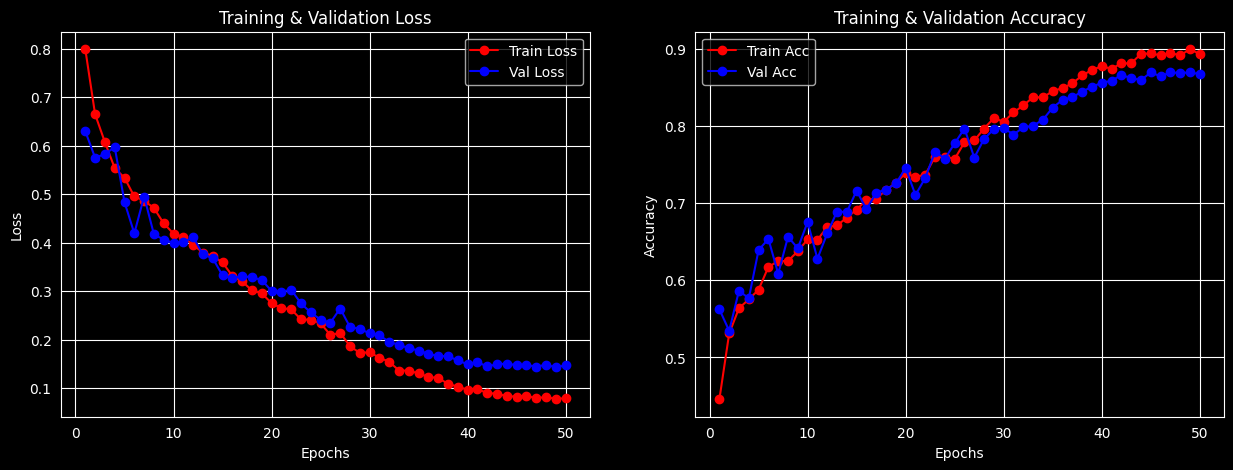

In [73]:
def plot_metrics(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'ro-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'bo-', label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'ro-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'bo-', label='Val Acc')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_metrics(history)


Dataset loaded successfully!
Total images: 7025
Training on:  5620 images (80%)
Validating on:1405 images (20%)
Classes: ['Broken Line', 'Edge False Color', 'Over Desaturation', 'Saturated False Color', 'Smears']



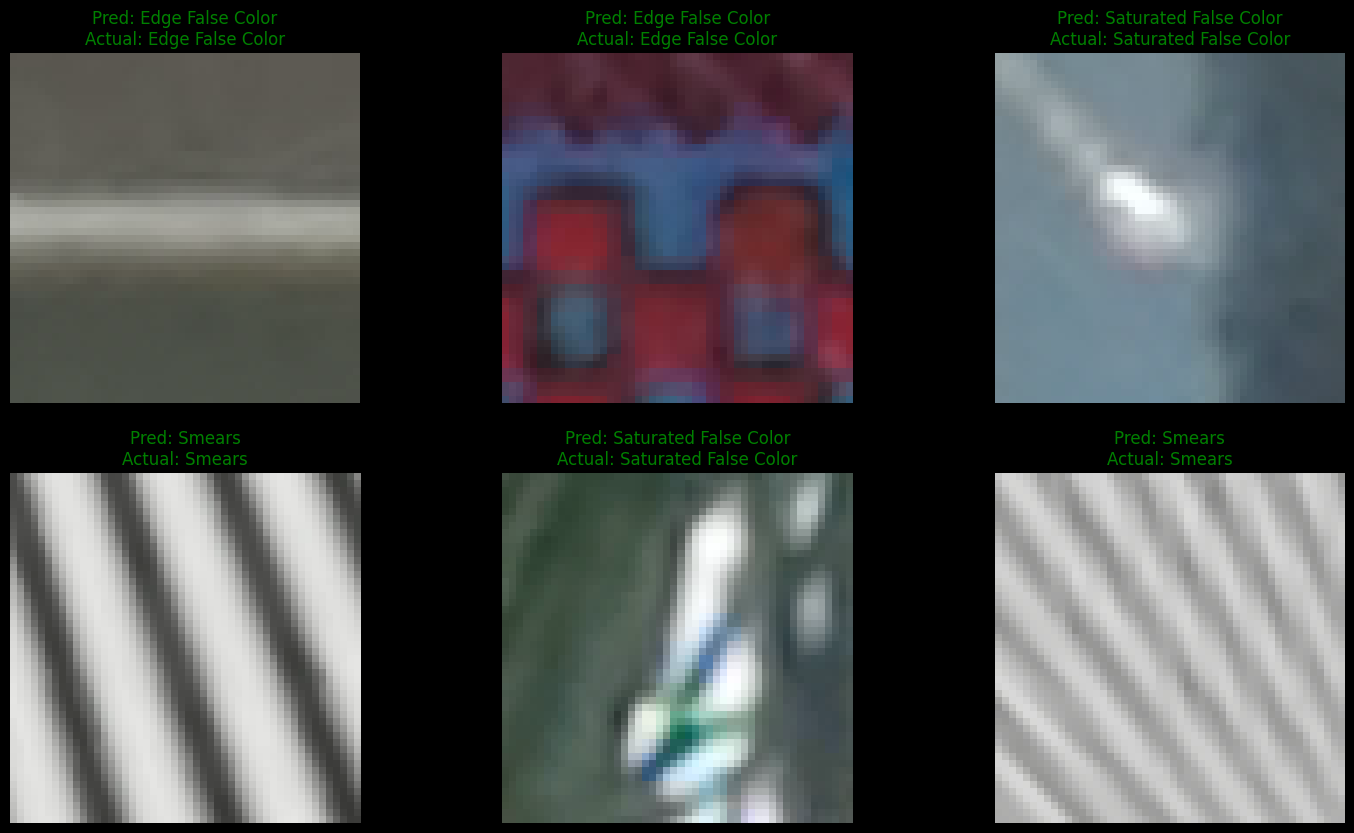

In [77]:
def visualize_results(model, data_dir, classes, num_images=6):
    model.eval()
    _, val_loader, _ = get_dataloaders(data_dir, batch_size=num_images)
    inputs, labels = next(iter(val_loader))
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(18, 10))
    for i in range(num_images):
        plt.subplot(2, 3, i + 1)
        img = inputs[i].cpu().numpy().transpose((1, 2, 0))
        img = DATASET_STD * img + DATASET_MEAN
        img = img.clip(0, 1)

        color = 'green' if preds[i] == labels[i] else 'red'
        plt.imshow(img)
        plt.title(f"Pred: {classes[preds[i]]}\nActual: {classes[labels[i]]}", color=color)
        plt.axis('off')
    plt.show()

visualize_results(model, DATA_DIR, classes)

In [78]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 20,211,781
Trainable Parameters: 20,211,781
